# Data Transformation :
Data transformation is a crucial step in the machine learning pipeline. It involves converting raw data into a suitable format for modeling, improving the accuracy and efficiency of the algorithm. The goal is to transform the data in a way that:
- Scales numerical values to a common range
- Handles missing or outlier values
- Encodes categorical variables as numerical values
- Reduces dimensionality and noise
In this example, we will perform the following data transformations:
# 1.Standard Scaling/Standardization
- Standard Scaling is a technique used to scale the data to have a mean of 0 and a standard deviation of 1. 
- This is done by subtracting the mean and then dividing by the standard deviation. 
- This is useful for many machine learning algorithms that assume the data is normally distributed.
- Standard Scaling is often used in combination with other scaling techniques, such as min-max scaling, to improve the performance of the model.

X_scaled = (X - μ) / σ

where:

- X_scaled is the scaled value of X
- X is the original value
- μ is the mean of X
- σ is the standard deviation of X

In [2]:
# import libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [4]:
# make an example dataset of age , weight and height for 5 people
data = {
    'age': [25, 30, 35, 40, 45],
    'weight': [60, 70, 80, 90, 100],
    'height': [170, 180, 190, 200, 210]
    }
df = pd.DataFrame(data)
df

,age,weight,height
0,25,60,170
1,30,70,180
2,35,80,190
3,40,90,200
4,45,100,210


In [ ]:
# create model 
scaler = StandardScaler()
# train the model 
scaled_df = scaler.fit_transform(df)

# create a new dataframe with the scaled values
scaled_df = pd.DataFrame(scaled_df,columns=df.columns)
scaled_df

,age,weight,height
0,-1.414214,-1.414214,-1.414214
1,-0.707107,-0.707107,-0.707107
2,0.000000,0.000000,0.000000
3,0.707107,0.707107,0.707107
4,1.414214,1.414214,1.414214


# 2.Min Max Scaling 
- If model deals with negative values, we can use StandardScaler
- If model cannot deal with negative values, we can use MinMaxScaler

In [10]:
# import libraries
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

df = pd.DataFrame(data)
# create model 
scaler = MinMaxScaler()
# train the model 
scaled_df = scaler.fit_transform(df)

# create a new dataframe with the scaled values
scaled_df = pd.DataFrame(scaled_df,columns=df.columns)
scaled_df

,age,weight,height
0,0.00,0.00,0.00
1,0.25,0.25,0.25
2,0.50,0.50,0.50
3,0.75,0.75,0.75
4,1.00,1.00,1.00


# 3.Max Abs Scaler 
**When to Use MaxAbs Scaler?**
1. You want to preserve the sparsity of the data.
2. You have features with constant values.
3. You want to avoid division by zero.
4. You want to improve the interpretability of the data.
5. You are working with L1-based models.

In [11]:
# import libraries
import pandas as pd
from sklearn.preprocessing import MaxAbsScaler

df = pd.DataFrame(data)
# create model 
scaler = MaxAbsScaler()
# train the model 
scaled_df = scaler.fit_transform(df)

# create a new dataframe with the scaled values
scaled_df = pd.DataFrame(scaled_df,columns=df.columns)
scaled_df

,age,weight,height
0,0.555556,0.6,0.809524
1,0.666667,0.7,0.857143
2,0.777778,0.8,0.904762
3,0.888889,0.9,0.952381
4,1.000000,1.0,1.000000


# 4.Robust Scaler 

✨ **Why Use Robust Scaler?**
- ✅ Outlier Resistant: Perfect for datasets with many outliers.

- ✅ Stable Transformation: Avoids distortion caused by extreme values.

- ✅ Model Friendly: Improves performance of models sensitive to feature scale.

In [12]:
# import libraries
import pandas as pd
from sklearn.preprocessing import RobustScaler

df = pd.DataFrame(data)
# create model 
scaler = RobustScaler()
# train the model 
scaled_df = scaler.fit_transform(df)

# create a new dataframe with the scaled values
scaled_df = pd.DataFrame(scaled_df,columns=df.columns)
scaled_df

,age,weight,height
0,-1.0,-1.0,-1.0
1,-0.5,-0.5,-0.5
2,0.0,0.0,0.0
3,0.5,0.5,0.5
4,1.0,1.0,1.0


---
# Transformation

In [13]:
# import libraries 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [14]:
np.random.seed(0)
data = np.random.exponential(size=1000,scale=2)
df = pd.DataFrame(data,columns=['values'])
df.head()

,values
0,1.591749
1,2.511862
2,1.846446
3,1.574402
4,1.102097


<Axes: ylabel='Count'>

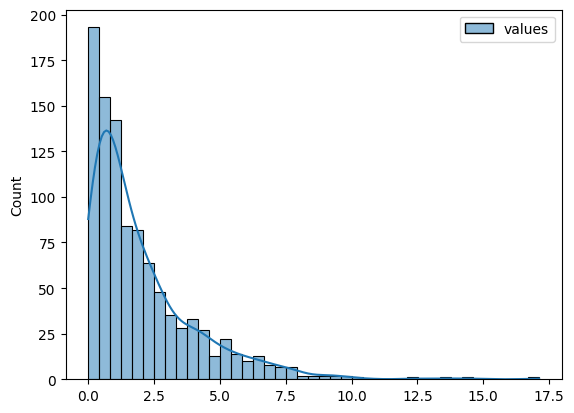

In [15]:
# Lets take a view of data distribution by making histogram 
sns.histplot(data=df,kde=True)

In [34]:
# power transformer to transform data to normal distribution
from sklearn.preprocessing import PowerTransformer 
from sklearn.preprocessing import QuantileTransformer

pt_box_cox = PowerTransformer(method='box-cox')
pt_yeo_johnson = PowerTransformer(method= 'yeo-johnson')
plt_normal = QuantileTransformer(output_distribution='normal')

df['Box Cox'] = pt_box_cox.fit_transform(df[['values']]+1)
df['Yeo Johnson'] = pt_yeo_johnson.fit_transform(df[['values']]) 
df['Quantile'] = plt_normal.fit_transform(df[['values']])

In [36]:
df.head()

,values,Box Cox,Yeo Johnson,Quantile
0,1.591749,0.179335,0.179335,0.162552
1,2.511862,0.677331,0.677331,0.587964
2,1.846446,0.339698,0.339698,0.286135
3,1.574402,0.167607,0.167607,0.157469
4,1.102097,-0.202107,-0.202107,-0.154930


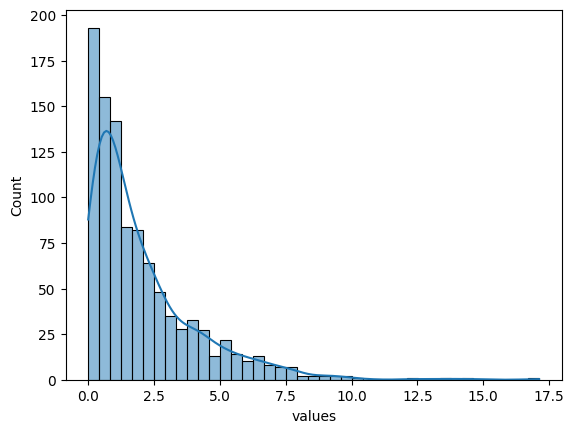

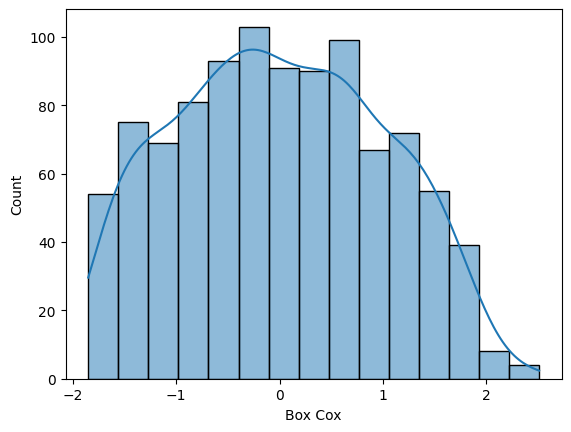

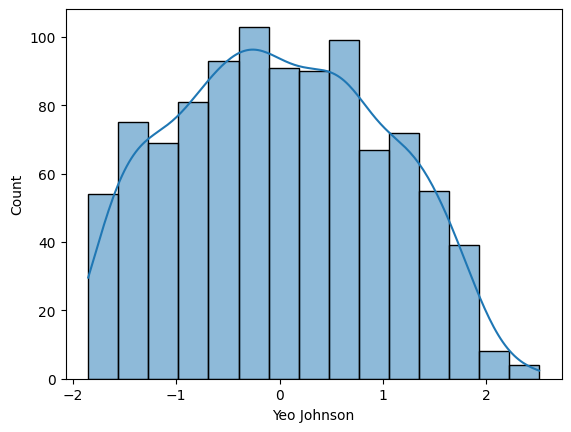

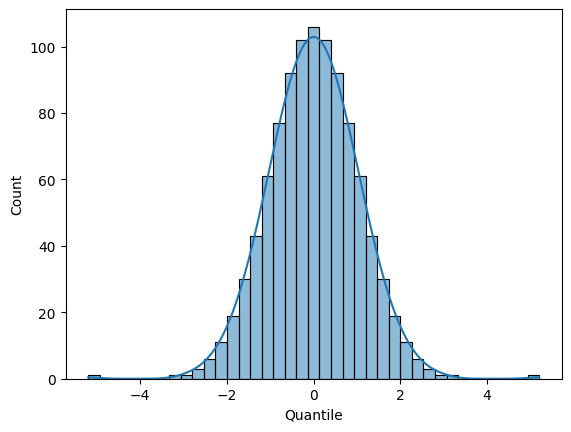

In [37]:
# print histplot with seaborn for each column in the dataframe
for col in df.columns:
    fig=sns.histplot(df[col],kde=True)
    plt.show()


---
# Normalization

## L2 Normalization
Rescales each sample (row) to have unit norm. This type of normalization is often used when dealing with text data. The L2 norm is calculated as the square root of the sum of the squared vector values.

In [42]:
from sklearn.preprocessing import Normalizer
data = [[1,1,0],[1,1,1],[1,0,0]]
df = pd.DataFrame(data,columns=['Val1','Val2','Val3'])
normalizer = Normalizer(norm='l2')
df_normal = normalizer.fit_transform(df)
df_normal = pd.DataFrame(df_normal)
df_normal

,0,1,2
0,0.707107,0.707107,0.00000
1,0.577350,0.577350,0.57735
2,1.000000,0.000000,0.00000


## L1 Normalization
Also rescales each sample (row) but with a different approach, ensuring the sum of the absolute values is 1 in each row. The L1 norm is calculated as the sum of the absolute vector values. Example:

In [43]:
from sklearn.preprocessing import Normalizer
data = [[1,1,0],[1,1,1],[1,0,0]]
df = pd.DataFrame(data,columns=['Val1','Val2','Val3'])
normalizer = Normalizer(norm='l1')
df_normal = normalizer.fit_transform(df)
df_normal = pd.DataFrame(df_normal)
df_normal

,0,1,2
0,0.500000,0.500000,0.000000
1,0.333333,0.333333,0.333333
2,1.000000,0.000000,0.000000


# Log Transformation 

In [44]:
import pandas as pd
import numpy as np

# example dataset with skewed values
df = { "Values": [1,5,10,20,50,100,200,500,1000,2000,5000,10000,20000,50000,100000]}
df = pd.DataFrame(df)
df.head()

,Values
0,1
1,5
2,10
3,20
4,50


In [45]:
df['log_values'] = np.log(df['Values'])
df

,Values,log_values
0,1,0.000000
1,5,1.609438
2,10,2.302585
3,20,2.995732
4,50,3.912023
5,100,4.605170
6,200,5.298317
7,500,6.214608
8,1000,6.907755
9,2000,7.600902
